# Spanish Translation A/B Test
A data scientist at XYZ noticed that Spain-based users have a much higher conversion rate than any other Spanish-speaking country. One reason could be translation. The team ran the A/B test where each country would have its one translation written by a local. The result is surprised that the non-localized translation was doing better.

You are asked to:

1. Confirm that the test is actually negative. That is, it appears that the old version of the site with just one translation across Spain and LatAm performs better
2. Explain why that might be happening. Are the localized translations really worse?
3. If you identified what was wrong, design an algorithm that would return FALSE if the same problem is happening in the future and TRUE if everything is good and the results can be trusted

## 1. IMPORT REQUIRED LIBRARIES

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from sklearn.tree import DecisionTreeClassifier, export_text

## 2. LOAD DATASET

In [69]:
user = pd.read_csv("user_table.csv")
test = pd.read_csv("test_table.csv")

print("User table shape:", user.shape)
print("Test table shape:", test.shape)

User table shape: (452867, 4)
Test table shape: (453321, 9)


## 3. Initial Data Inspection

Before performing any statistical analysis, we inspect the structure and first few observations of the datasets.

In [70]:
user.head()

,user_id,sex,age,country
0,765821,M,20,Mexico
1,343561,F,27,Nicaragua
2,118744,M,23,Colombia
3,987753,F,27,Venezuela
4,554597,F,20,Spain


In [71]:
test.head()

,user_id,date,source,device,browser_language,ads_channel,browser,conversion,test
0,315281,2015-12-03,Direct,Web,ES,NaN,IE,1,0
1,497851,2015-12-04,Ads,Web,ES,Google,IE,0,1
2,848402,2015-12-04,Ads,Web,ES,Facebook,Chrome,0,0
3,290051,2015-12-03,Ads,Mobile,Other,Facebook,Android_App,0,1
4,548435,2015-11-30,Ads,Web,ES,Google,FireFox,0,1


In [72]:
print("User table information:")
user.info()

print("\nTest table information:")
test.info()

User table information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452867 entries, 0 to 452866
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   user_id  452867 non-null  int64 
 1   sex      452867 non-null  object
 2   age      452867 non-null  int64 
 3   country  452867 non-null  object
dtypes: int64(2), object(2)
memory usage: 13.8+ MB

Test table information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453321 entries, 0 to 453320
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   user_id           453321 non-null  int64 
 1   date              453321 non-null  object
 2   source            453321 non-null  object
 3   device            453321 non-null  object
 4   browser_language  453321 non-null  object
 5   ads_channel       181877 non-null  object
 6   browser           453321 non-null  object
 7   conversion        453321

## 4. Check for Duplicate Users

A valid A/B testing dataset should ideally contain one record per user in each table.

Duplicate `user_id` values could lead to incorrect conversion calculations and biased statistical results.

In [73]:
print("Duplicate user IDs in user table:",
      user['user_id'].duplicated().sum())

print("Duplicate user IDs in test table:",
      test['user_id'].duplicated().sum())

Duplicate user IDs in user table: 0
Duplicate user IDs in test table: 0


In [74]:
print("Number of users:", len(user))
print("Number of test records:", len(test))
print("Difference:", len(user) - len(test))

Number of users: 452867
Number of test records: 453321
Difference: -454


From the length of two tables, we can find that we have some user_id missing in the user_table.

When joining, we have to be careful to do not lose the user_ids in the test table, but not in the user table.

## 5. Merge the Datasets

The experiment table is used as the base table because it contains the complete set of users who participated in the experiment.

A **left join** ensures that users present in the test table are not accidentally removed when demographic information is missing from the user table.

In [75]:
data = pd.merge(
    test,
    user,
    on='user_id',
    how='left'
)

data['date'] = pd.to_datetime(data['date'])

print("Final dataset shape:", data.shape)

Final dataset shape: (453321, 12)


## 6. Dataset Overview

In [76]:
data.head()

,user_id,date,source,device,browser_language,ads_channel,browser,conversion,test,sex,age,country
0,315281,2015-12-03,Direct,Web,ES,NaN,IE,1,0,M,32.0,Spain
1,497851,2015-12-04,Ads,Web,ES,Google,IE,0,1,M,21.0,Mexico
2,848402,2015-12-04,Ads,Web,ES,Facebook,Chrome,0,0,M,34.0,Spain
3,290051,2015-12-03,Ads,Mobile,Other,Facebook,Android_App,0,1,F,22.0,Mexico
4,548435,2015-11-30,Ads,Web,ES,Google,FireFox,0,1,M,19.0,Mexico


In [77]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453321 entries, 0 to 453320
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           453321 non-null  int64         
 1   date              453321 non-null  datetime64[ns]
 2   source            453321 non-null  object        
 3   device            453321 non-null  object        
 4   browser_language  453321 non-null  object        
 5   ads_channel       181877 non-null  object        
 6   browser           453321 non-null  object        
 7   conversion        453321 non-null  int64         
 8   test              453321 non-null  int64         
 9   sex               452867 non-null  object        
 10  age               452867 non-null  float64       
 11  country           452867 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(7)
memory usage: 41.5+ MB


In [78]:
data.describe()

,user_id,date,conversion,test,age
count,453321.000000,453321,453321.000000,453321.000000,452867.000000
mean,499937.514728,2015-12-02 08:56:07.976334336,0.049579,0.476446,27.130740
min,1.000000,2015-11-30 00:00:00,0.000000,0.000000,18.000000
25%,249816.000000,2015-12-01 00:00:00,0.000000,0.000000,22.000000
50%,500019.000000,2015-12-03 00:00:00,0.000000,0.000000,26.000000
75%,749522.000000,2015-12-04 00:00:00,0.000000,1.000000,31.000000
max,1000000.000000,2015-12-04 00:00:00,1.000000,1.000000,70.000000
std,288665.193436,NaN,0.217073,0.499445,6.776678


## 7. Missing Value Analysis

Missing values are checked before analysis because demographic variables may not be available for every user.

Importantly, missing demographic information should not cause experiment participants to be removed unnecessarily.

In [79]:
missing = (
    data.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": (missing / len(data) * 100).round(2)
})

display(missing_df[missing_df["Missing Values"] > 0])

,Missing Values,Missing %
ads_channel,271444,59.88
sex,454,0.10
country,454,0.10
age,454,0.10


## 8. Exploratory Data Analysis

Before evaluating the A/B test, we examine the distribution of users and conversions across important variables.

This helps identify unusual patterns that could affect the experiment.

### i). Test vs Control Distribution

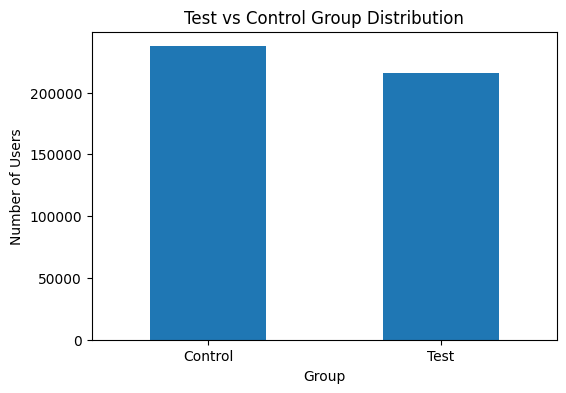

In [80]:
group_counts = data["test"].value_counts().sort_index()

group_counts.index = ["Control", "Test"]

group_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Test vs Control Group Distribution")
plt.ylabel("Number of Users")
plt.xlabel("Group")
plt.xticks(rotation=0)
plt.show()

### ii) Overall Conversion Rate

Conversion rate is calculated as:

$$
Conversion\ Rate = \frac{Number\ of\ Conversions}{Total\ Users}
$$

We first calculate the conversion rate for the control and test groups separately.

In [81]:
conversion_by_group = (
    data.groupby("test")["conversion"]
    .mean()
)

conversion_by_group.index = ["Control", "Test"]

display(conversion_by_group)

Control    0.055179
Test       0.043425
Name: conversion, dtype: float64

## iii). Visualizing Conversion Rates

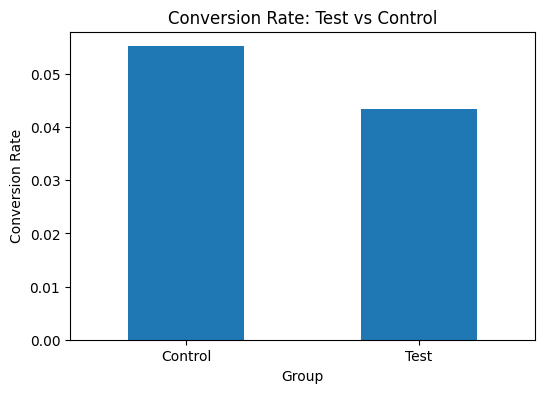

In [82]:
conversion_by_group.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Conversion Rate: Test vs Control")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")
plt.xticks(rotation=0)
plt.show()

## 9. Country-Level Baseline Analysis

Before interpreting the experiment, we examine conversion rates by country for the control group.

This is important because different countries may have significantly different baseline conversion rates.

A country with unusually high conversion should not dominate the overall experiment result.

In [83]:
control_data = data[data['test'] == 0]

country_conversion = (
    control_data
    .groupby('country')['conversion']
    .mean()
    .reset_index()
    .sort_values('conversion', ascending=False)
)

country_conversion.head(10)

,country,conversion
14,Spain,0.079719
6,El Salvador,0.053554
10,Nicaragua,0.052647
4,Costa Rica,0.052256
3,Colombia,0.052089
8,Honduras,0.050906
7,Guatemala,0.050643
16,Venezuela,0.050344
13,Peru,0.049914
9,Mexico,0.049495


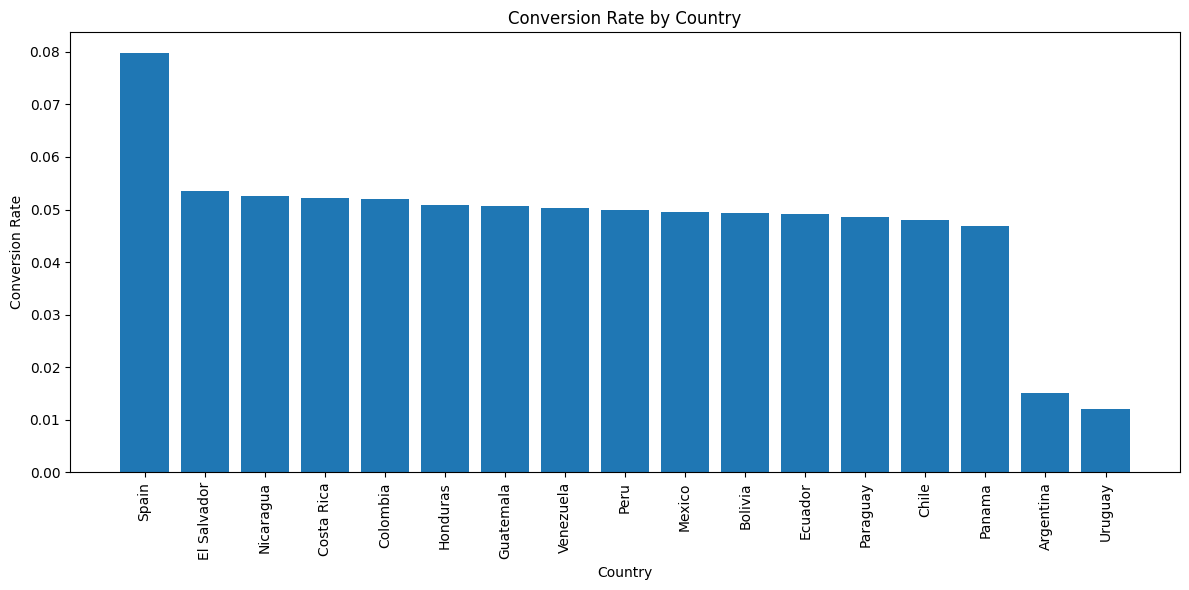

In [84]:
plt.figure(figsize=(12, 6))

plt.bar(
    country_conversion['country'],
    country_conversion['conversion']
)

plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Country")

plt.tight_layout()
plt.show()

### Insight

Spain has a substantially higher baseline conversion rate than the major Latin American markets.

Therefore, Spain should be treated separately when evaluating the effectiveness of the Spanish translation.

Including Spain directly in the overall analysis could distort the results because its users already exhibit unusually high conversion.

## 10. Remove Spain for the Main A/B Test

Since Spain already has a significantly higher baseline conversion rate, we exclude it from the primary experiment analysis.

The remaining dataset represents the Latin American markets where the translation is intended to provide incremental value.

In [85]:
data_test = data[data['country'] != 'Spain'].copy()

print("Original data:", data.shape)
print("Data after removing Spain:", data_test.shape)

Original data: (453321, 12)
Data after removing Spain: (401539, 12)


## 11. Define Hypotheses

We use a two-sided hypothesis test.

#### Null Hypothesis (H₀)

There is **no difference** in conversion rates between the translated website and the original website.

$$
H_0: \mu_{test} = \mu_{control}
$$

#### Alternative Hypothesis (H₁)

There is a difference in conversion rates between the two groups.

$$
H_1: \mu_{test} \neq \mu_{control}
$$

We use a significance level:

$$
\alpha = 0.05
$$

## 12. Overall A/B Test

We perform Welch's independent two-sample t-test.

Welch's t-test is preferred because it does not require the two groups to have equal variance.

In [86]:
test_group = data_test[
    data_test['test'] == 1
]['conversion']

control_group = data_test[
    data_test['test'] == 0
]['conversion']

print("Test users:", len(test_group))
print("Control users:", len(control_group))

Test users: 215983
Control users: 185556


In [87]:
test_conversion = test_group.mean()
control_conversion = control_group.mean()

print("Test conversion rate:", test_conversion)
print("Control conversion rate:", control_conversion)

Test conversion rate: 0.043424713982118966
Control conversion rate: 0.04833042316066309


In [88]:
print(f"Test conversion rate: {test_conversion * 100:.2f}%")
print(f"Control conversion rate: {control_conversion * 100:.2f}%")

Test conversion rate: 4.34%
Control conversion rate: 4.83%


In [89]:
t_stat, p_value = ttest_ind(
    test_group,
    control_group,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -7.393937412134479
P-value: 1.4282994754055473e-13


### i). Measure the Relative Change

We calculate the percentage change in conversion rate:

$$
Relative\ Change =
\frac{Test-Control}{Control}\times100
$$

In [90]:
percentage_change = (
    (test_conversion - control_conversion)
    / control_conversion
) * 100

print(f"Relative change: {percentage_change:.2f}%")

Relative change: -10.15%


## Statistical Result

The test group shows a lower conversion rate than the control group.

The p-value is far below 0.05, indicating that the overall difference is statistically significant.

However, statistical significance alone does not establish that the translation itself caused the decline.

We therefore investigate whether the experiment was properly randomized.

## 13. Conversion Trend Over Time

The experiment ran for only a few days.

We compare the test and control conversion rates by day to determine whether the performance difference is consistent over time.

In [91]:
daily_results = (
    data_test
    .groupby(['date', 'test'])['conversion']
    .mean()
    .unstack()
)

daily_results.columns = ['Control', 'Test']

daily_results['Test_vs_Control'] = (
    daily_results['Test'] /
    daily_results['Control']
)

daily_results


,Control,Test,Test_vs_Control
date,,,
2015-11-30,0.051378,0.043886,0.854179
2015-12-01,0.046287,0.041387,0.894141
2015-12-02,0.048550,0.044234,0.911090
2015-12-03,0.049284,0.043884,0.890439
2015-12-04,0.047043,0.043491,0.924486


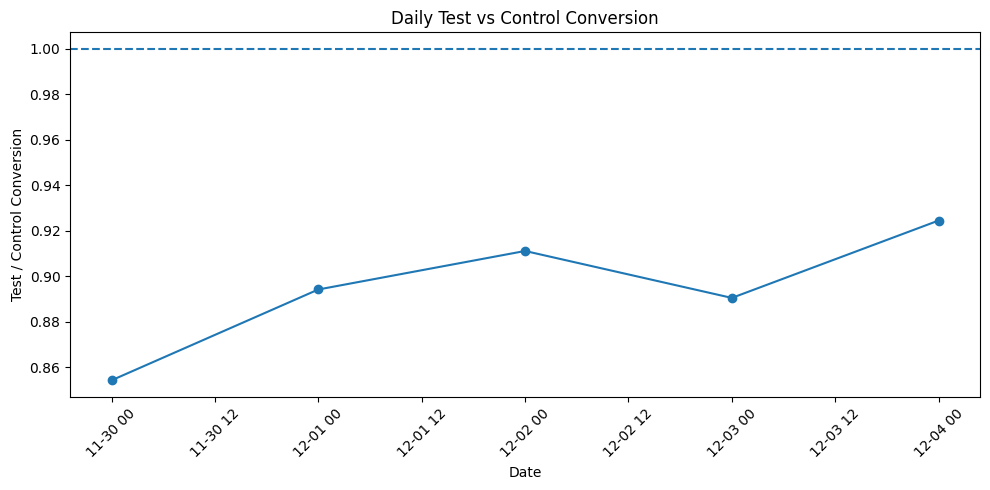

In [92]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_results.index,
    daily_results['Test_vs_Control'],
    marker='o'
)

plt.axhline(
    y=1,
    linestyle='--'
)

plt.xlabel("Date")
plt.ylabel("Test / Control Conversion")
plt.title("Daily Test vs Control Conversion")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###  Insight

The test group consistently performs below the control group across the observed days.

However, the experiment covers only a short period.

For a production decision, the experiment should ideally run for at least one complete business cycle and preferably around 1–2 weeks, depending on traffic volume and business seasonality.

More importantly, the next analysis checks whether the difference is caused by an imbalance in experiment assignment.

## 14. Randomization / Experiment Bias Analysis

A properly designed A/B test should distribute users approximately evenly between test and control groups across important characteristics.

We investigate whether certain countries were disproportionately assigned to the test group.

A decision tree can help identify variables that predict experiment assignment.

In [93]:
tree_data = data_test[
    ["test", "country", "source", "device",
     "browser_language", "ads_channel",
     "browser", "sex", "age"]
].copy()

tree_data = pd.get_dummies(
    tree_data,
    columns=[
        "country",
        "source",
        "device",
        "browser_language",
        "ads_channel",
        "browser",
        "sex"
    ],
    drop_first=False
)

tree_data = tree_data.fillna(0)

X = tree_data.drop(columns="test")
y = tree_data["test"]

In [94]:
tree_model = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=0.01,
    random_state=42
)

tree_model.fit(X, y)

print(export_text(
    tree_model,
    feature_names=list(X.columns)
))

|--- country_Argentina <= 0.50
|   |--- country_Uruguay <= 0.50
|   |   |--- class: 0
|   |--- country_Uruguay >  0.50
|   |   |--- class: 1
|--- country_Argentina >  0.50
|   |--- browser_Safari <= 0.50
|   |   |--- class: 1
|   |--- browser_Safari >  0.50
|   |   |--- class: 1



##  Key Finding: Randomization Bias

The decision tree reveals that country is a strong predictor of experiment assignment.

In particular, users from **Argentina and Uruguay** are disproportionately represented in the test group, while most other countries are much closer to a 50/50 split.

This means the original experiment was not perfectly randomized.

### Why is this important?

Argentina and Uruguay have relatively low baseline conversion rates.

If a larger proportion of users from these countries were placed in the test group, the overall test conversion rate could appear artificially low even if the translation itself had little or no negative effect.

Therefore, the overall A/B test result is potentially confounded by country-level imbalance.

## 15. Test vs Control Assignment by Country

We directly calculate the proportion of users assigned to the test group in each country.

In [95]:
country_assignment = (
    data_test
    .groupby("country")["test"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

country_assignment["test_percentage"] = (
    country_assignment["mean"] * 100
)

country_assignment = country_assignment.drop(columns="mean")

display(country_assignment)

,count,test_percentage
country,,
Uruguay,4134,89.961297
Argentina,46733,79.979886
Paraguay,7347,50.319858
Panama,3951,50.240445
Bolivia,11124,50.107875
Chile,19737,50.078533
Mexico,128484,50.025684
Costa Rica,5309,49.896402
Peru,33666,49.893067


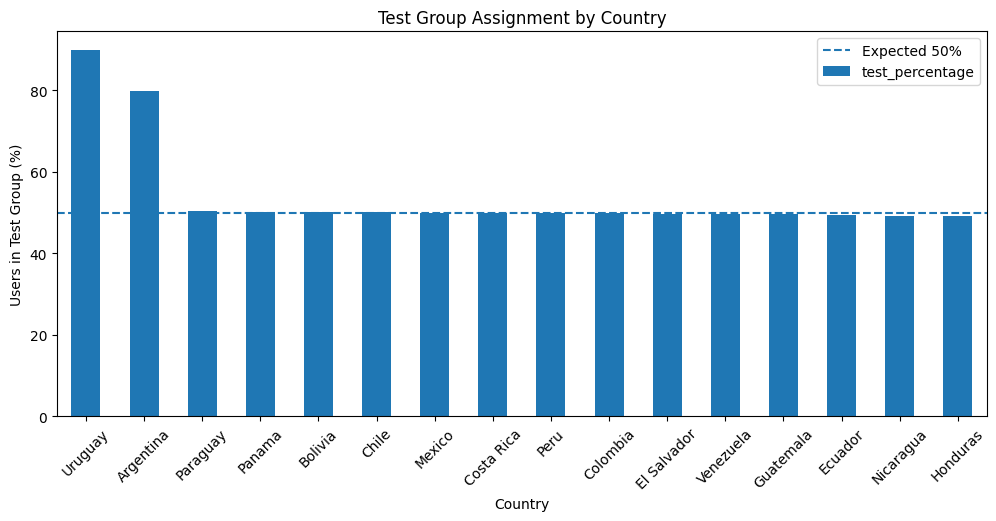

In [96]:
country_assignment["test_percentage"].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.axhline(
    50,
    linestyle="--",
    label="Expected 50%"
)

plt.title("Test Group Assignment by Country")
plt.ylabel("Users in Test Group (%)")
plt.xlabel("Country")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 16. Country-Level A/B Testing

To control for country-level differences, we perform a separate A/B test within each country.

This helps answer:

> "Within the same country, does the Spanish translation significantly change conversion?"

Welch's t-test is used for each country.

In [97]:
country_results = []

for country, group in data_test.groupby("country"):
    
    test_conversion_country = group.loc[
        group["test"] == 1, "conversion"
    ]
    
    control_conversion_country = group.loc[
        group["test"] == 0, "conversion"
    ]
    
    if len(test_conversion_country) > 1 and len(control_conversion_country) > 1:
        
        t_stat, country_p_value = ttest_ind(
            test_conversion_country,
            control_conversion_country,
            equal_var=False
        )
        
        country_results.append({
            "country": country,
            "test_conversion": test_conversion_country.mean(),
            "control_conversion": control_conversion_country.mean(),
            "difference": (
                test_conversion_country.mean()
                - control_conversion_country.mean()
            ),
            "p_value": country_p_value
        })

country_results = pd.DataFrame(country_results)

country_results = country_results.sort_values(
    "p_value"
)

display(country_results)

,country,test_conversion,control_conversion,difference,p_value
9,Mexico,0.051186,0.049495,0.001692,0.165544
6,El Salvador,0.047947,0.053554,-0.005607,0.248127
2,Chile,0.051295,0.048107,0.003188,0.302848
0,Argentina,0.013725,0.015071,-0.001346,0.335147
3,Colombia,0.050571,0.052089,-0.001519,0.423719
8,Honduras,0.047540,0.050906,-0.003366,0.471463
7,Guatemala,0.048647,0.050643,-0.001996,0.572107
15,Venezuela,0.048978,0.050344,-0.001365,0.573702
4,Costa Rica,0.054738,0.052256,0.002482,0.687876
11,Panama,0.049370,0.046796,0.002575,0.705327


## 17. Statistical Significance by Country

We use:

$$
\alpha = 0.05
$$

Therefore:

- **p-value < 0.05** → statistically significant difference
- **p-value ≥ 0.05** → insufficient evidence of a significant difference

In [98]:
country_results["significant"] = np.where(
    country_results["p_value"] < 0.05,
    "Yes",
    "No"
)

display(country_results)

,country,test_conversion,control_conversion,difference,p_value,significant
9,Mexico,0.051186,0.049495,0.001692,0.165544,No
6,El Salvador,0.047947,0.053554,-0.005607,0.248127,No
2,Chile,0.051295,0.048107,0.003188,0.302848,No
0,Argentina,0.013725,0.015071,-0.001346,0.335147,No
3,Colombia,0.050571,0.052089,-0.001519,0.423719,No
8,Honduras,0.047540,0.050906,-0.003366,0.471463,No
7,Guatemala,0.048647,0.050643,-0.001996,0.572107,No
15,Venezuela,0.048978,0.050344,-0.001365,0.573702,No
4,Costa Rica,0.054738,0.052256,0.002482,0.687876,No
11,Panama,0.049370,0.046796,0.002575,0.705327,No


##  Country-Level Insight

After controlling for country, none of the individual markets shows a statistically significant difference in conversion at the 5% significance level.

This suggests that the large overall difference between test and control is not consistently observed within individual countries.

The evidence therefore points toward **experiment design / randomization bias rather than a genuine negative impact of the translation**.

## 18. Country-Level Conversion Comparison

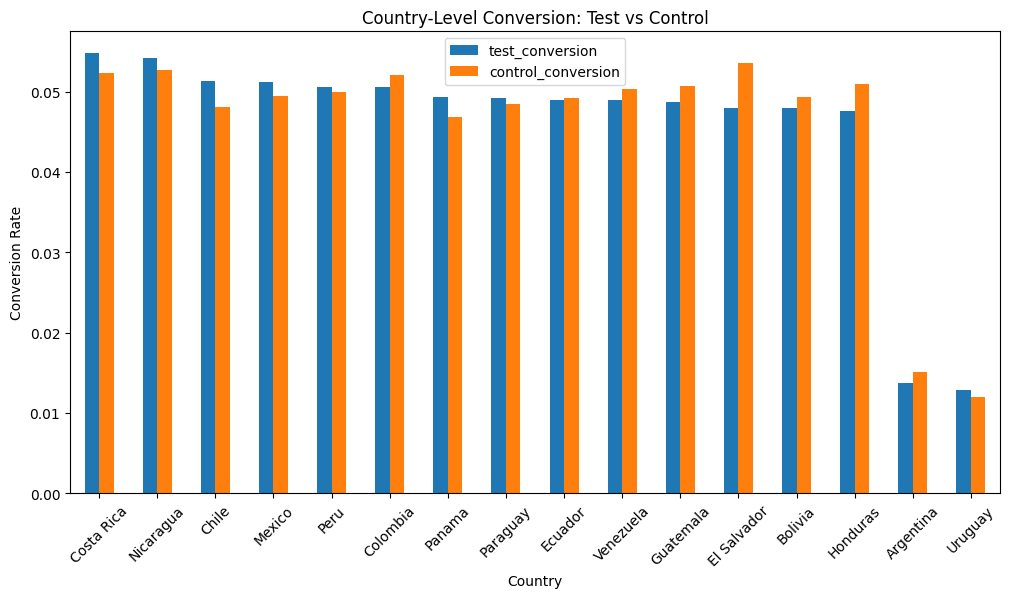

In [99]:
country_results_sorted = country_results.sort_values(
    "test_conversion",
    ascending=False
)

country_results_sorted.set_index("country")[
    ["test_conversion", "control_conversion"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Country-Level Conversion: Test vs Control")
plt.ylabel("Conversion Rate")
plt.xlabel("Country")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 19. Key Findings

### Finding 1 — Overall Result

The Spanish translation group has a lower overall conversion rate than the control group.

The difference is statistically significant in the unadjusted analysis.

### Finding 2 — Spain Has an Unusually High Baseline

Spain has substantially higher baseline conversion than the major Latin American markets.

Therefore, Spain should not be combined blindly with the other countries.

### Finding 3 — Experiment Randomization Was Biased

Country distribution across the test and control groups was not perfectly balanced.

Argentina and Uruguay were disproportionately represented in the test group.

### Finding 4 — Country-Level Results Are Not Significant

When comparing test and control users within individual countries, no country shows a statistically significant conversion difference.

### Finding 5 — Translation Does Not Appear to Harm Conversion

The overall negative result appears to be strongly influenced by country-level imbalance rather than a consistent negative effect of the Spanish translation.

### Finding 6 — Experiment Duration Was Short

The experiment covered only a few days, so a longer experiment would provide more reliable evidence.

## 20. Business Recommendation

Based on the analysis, the Spanish translation should **not be rejected solely because of the lower overall conversion rate**.

The original experiment suffers from an important randomization issue.

### Recommended Actions

1. **Rerun the A/B test with proper randomization.**
2. Ensure approximately equal test/control assignment within each country.
3. Run the experiment for a longer period, preferably at least 1–2 weeks.
4. Analyze conversion at the country level.
5. Monitor other metrics such as engagement, bounce rate, session duration, and revenue per user.
6. Make the final launch decision using the properly randomized experiment.

### Final Decision

**Do not roll back the Spanish translation based on the current experiment.**

Instead, redesign and rerun the experiment to obtain an unbiased estimate of the translation's true impact.

## 21. Conclusion

This project demonstrates how A/B testing can be used to evaluate a product change while accounting for statistical significance and experimental design.

Although the initial analysis suggests that the Spanish translation reduces conversion, deeper analysis reveals that the experiment was affected by country-level assignment bias.

After controlling for country, the negative effect is no longer statistically significant.

### Final Takeaway

> **The experiment does not provide sufficient evidence that Spanish translation negatively impacts conversion. The test should be rerun using proper randomization before making a final business decision.**

This analysis highlights the importance of going beyond a simple p-value and checking whether an experiment was designed correctly before acting on its results.